# Atlas: End-to-End Pipeline
Este notebook executa o pipeline completo utilizando `configs/base.yaml`, gerando os resultados de walk-forward, comparando com o índice Ibovespa e exibindo KPIs resumidos.

**Roteiro do notebook:**
1. **Contexto da estratégia**: resume universo, sinais, construção de portfólio, gestão de risco e premissas de custo.
2. **Carregamento de configurações e painel**: carrega `configs/base.yaml`, monta o painel de preços/volumes e valida o recorte temporal.
3. **Qualidade e composição dos dados**: consolida checks de cobertura, duplicidade, nulos e liquidez do universo.
4. **Execu??o do walk-forward base**: roda o pipeline com janelas 504/126 para obter curva e KPIs de referência.
5. **Benchmark Ibovespa**: prepara a série normalizada do índice como baseline de mercado.
6. **Curvas de equity e KPIs agregados**: plota walk-forward/benchmark e sintetiza CAGR, Sharpe/Sortino em excesso a Selic, volatilidade e drawdown.
7. **KPIs por janela de walk-forward**: detalha métricas por janela out-of-sample para avaliar consistência temporal.
8. **Benchmark walk-forward vs Ibovespa**: Comparamos diretamente a estrategia walk-forward com o Ibovespa, destacando a divergencia acumulada entre as curvas e relatando KPIs absolutos e relativos.
9. **Cenário adicional de risco**: reexecuta o walk-forward com `target_vol=0.14` e `vol_mult=1.4` como alternativa mais conservadora.
10. **Comparação das curvas e KPIs**: confronta base vs cenário alternativo e exibe deltas de performance.
11. **Testes de robustez e sensibilidade**: roda stress de custos e resume os principais pontos dos heatmaps de parâmetros.
12. **Robustez visual**: organiza heatmaps e stress tests em gráficos para argumentação visual.
13. **Intervalos de confiança para KPIs**: aplica bootstrap em blocos (21 dias) para quantis de CAGR, Sharpe e MaxDD.
14. **Interpretação dos testes**: traduz intervalos, PSR e p-values em implicações práticas para cada cenário.
15. **Conclusões**: destaca trade-offs de risco/retorno, significância estatística e robustez observada.


### 1. Contexto da estratégia
Atlas é um pipeline de alocação long-only para o universo brasileiro, combinando heurísticas topológicas e fatores clássicos para entregar risco equilibrado em múltiplos regimes. A seguir resumimos as premissas que embasam os resultados apresentados.

- **Universo e dados**: trabalhamos com os constituintes do Ibovespa em cada quadrimestre, filtrando os 20 ativos mais líquidos (ADV > BRL 500k, preço > BRL 5, idade > 20 pregões) no intervalo de 14/09/2017 a 06/10/2025. O painel é diário, multi-indexado por data/ativo e inclui volumes para controle de capacidade.
- **Sinais e modelos**: o motor de previsibilidade combina momentum 12-1, qualidade e carry com camadas de topologia. Usamos o índice de turbulência por homologia persistente (janela 30, `alert_sigma` 0.58, `riskoff_sigma` 1.8) e o Mapper para classificar regimes/periferia. Um meta-blend ElasticNet (rolling 126d, CV purged) aprende pesos ótimos entre fatores, optionalmente condicionados ao regime.
- **Construção de portfólio**: geramos pesos base via Hierarchical Risk Parity, ajustados por vieses de periferia (`periphery_bias_lambda=1.0`) e tilts de retorno esperado limitados a 3%. O portfólio é long-only e redistribui pesos para respeitar restrições de cluster e participação.
- **Gestão de risco**: o alvo de volatilidade é 12% com multiplicador de 1.6 e escalonamento por regime (`scale_low=0.85`, `scale_high=1.2`). Há kill-switch por drawdown (lookback 60d, limite -15%), cooldown de 21 dias e caps de turnover (25%) e participation (5%, modulados por regime).
- **Custos e operacionalização**: incorporamos fees de 10 bps, slippage não linear (`k=0.1`, teto 50 bps) e controles de participação para aproximar execução realista. O cenário alternativo avalia `target_vol=0.14` e `vol_mult=1.4`, refletindo um perfil mais conservador observado nos heatmaps de robustez.

Esse contexto garante que as métricas das seções seguintes sejam lidas com as premissas corretas de dados, modelo e controles operacionais.

### 2. Carregamento de configurações e painel
Carregamos o YAML base (`configs/base.yaml`) e o painel de preços/volumes do Ibovespa. Também contabilizamos o número de observações e ativos únicos para garantir que o recorte temporal está coerente.

In [1]:
from pathlib import Path
import sys
import logging
import asyncio
import warnings

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.append(str(PROJECT_ROOT / "src"))

warnings.simplefilter('ignore', FutureWarning)
warnings.simplefilter('ignore', UserWarning)
if sys.platform.startswith('win'):
    asyncio.set_event_loop_policy(asyncio.WindowsSelectorEventLoopPolicy())
CONFIG_PATH = PROJECT_ROOT / "configs" / "base.yaml"
IBOV_PATH = PROJECT_ROOT / "data" / "benchmark" / "ibovespa_index_b3.csv"

logging.basicConfig(level=logging.WARNING, force=True)
print(f"Projeto: {PROJECT_ROOT}")
print(f"Config: {CONFIG_PATH}")
print(f"Ibovespa CSV: {IBOV_PATH}")

Projeto: D:\GitHub Dic\itau-quant-challenge-2025
Config: D:\GitHub Dic\itau-quant-challenge-2025\configs\base.yaml
Ibovespa CSV: D:\GitHub Dic\itau-quant-challenge-2025\data\benchmark\ibovespa_index_b3.csv


In [2]:
from copy import deepcopy
from dataio.config import load_config
from dataio.loaders import get_panel
import pandas as pd

cfg = load_config(CONFIG_PATH)
start = cfg["dates"]["start"]
end = cfg["dates"]["end"]
panel = get_panel(start, end)
asset_count = panel.index.get_level_values("asset").nunique()
print(f"Painel carregado: {start} -> {end}")
# Retornamos as primeiras linhas do painel para inspecionar rapidamente o formato (MultiIndex com data e ativo).
print(f"Observacoes: {panel.shape[0]} | Ativos unicos: {asset_count}")
panel.head()

Painel carregado: 2017-09-14 -> 2025-10-06
Observacoes: 136797 | Ativos unicos: 138


close       volume
date       asset                    
2017-09-14 ABEV3  21.19  171456071.0
           BBAS3  33.62  174286891.0
           BBDC3  33.92   46957064.0
           BBDC4  35.14  287782404.0
           BBSE3  28.96   89669285.0

### 3. Qualidade e composição dos dados
Antes de avaliar performance, garantimos que o painel atende aos requisitos de cobertura, consistência e liquidez do desafio: 

- **Cobertura temporal**: painel diário de 14/09/2017 a 06/10/2025 (504d IS / 126d OOS) alinhado às datas de walk-forward do `configs/base.yaml`.
- **Curadoria do universo**: Ibovespa quadrimestral com filtros de liquidez (ADV > BRL 500k), preço mínimo (BRL 5), idade (>20 pregões) e hysteresis de 4 rebalanceamentos para evitar churn excessivo.
- **Integridade**: verificamos duplicatas (date/asset), valores nulos em `close` e `volume`, e cobrimos o percentual de observações válidas em cada ativo.
- **Capacidade**: avaliamos os 5 ativos com maior ADV médio e o percentual de dias com volume zero para medir viabilidade de execução.

A tabela e os resumos da célula seguinte consolidam essas checagens para a amostra utilizada no pipeline.

In [3]:
panel_reset = panel.reset_index()

# Cobertura geral
summary_stats = pd.Series({
    'Observações': len(panel),
    'Dias úteis': panel_reset['date'].nunique(),
    'Ativos únicos': panel_reset['asset'].nunique(),
    'Duplicatas (date, asset)': int(panel.index.duplicated().sum()),
    'Missing close (%)': panel_reset['close'].isna().mean() * 100,
    'Missing volume (%)': panel_reset['volume'].isna().mean() * 100,
    'Dias com volume zero (%)': (panel_reset['volume'] == 0).mean() * 100,
}).to_frame(name='Valor')
summary_stats.loc[['Missing close (%)', 'Missing volume (%)', 'Dias com volume zero (%)']] = (
    summary_stats.loc[['Missing close (%)', 'Missing volume (%)', 'Dias com volume zero (%)']].round(4)
)
summary_stats

# Cobertura por ativo (top 5 por ADV diário médio)
liquidity = (
    panel_reset.groupby('asset')
    .agg(
        dias=('date', 'nunique'),
        primeira_data=('date', 'min'),
        ultima_data=('date', 'max'),
        adv_medio=('volume', 'mean'),
        pct_missing_close=('close', lambda s: s.isna().mean() * 100),
    )
    .sort_values('adv_medio', ascending=False)
    .head(5)
)
liquidity['adv_medio'] = liquidity['adv_medio'].round(0)
liquidity['pct_missing_close'] = liquidity['pct_missing_close'].round(4)
liquidity


,dias,primeira_data,ultima_data,adv_medio,pct_missing_close
asset,,,,,
VALE3,1723,2017-09-14,2025-10-06,1.650813e+09,0.0
PETR4,1723,2017-09-14,2025-10-06,1.642410e+09,0.0
ITUB4,1723,2017-09-14,2025-10-06,8.533993e+08,0.0
BBDC4,1723,2017-09-14,2025-10-06,6.941060e+08,0.0
VVAR3,504,2019-01-04,2021-08-02,6.170112e+08,0.0


### 4. Execução do walk-forward referência
Rodamos o walk-forward com janelas de 504 dias in-sample / 126 dias out-of-sample. Esse resultado serve como base de comparação contra o benchmark e contra cenários alternativos.

In [4]:
from validation.walk_forward import run_walk_forward
from validation import run_stat_validations

walkforward_cfg = deepcopy(cfg)
walkforward_result = run_walk_forward(walkforward_cfg, panel)
walkforward_equity = walkforward_result["equity_curve"].rename("Walk-forward")
walkforward_kpis = walkforward_result["kpis"]
walkforward_returns = walkforward_result["returns"]

walkforward_windows = walkforward_result.get("windows", [])
print(f"Walk-forward janelas: {len(walkforward_windows)}")
print(f"Walk-forward dias: {len(walkforward_equity)}")


Walk-forward janelas: 9
Walk-forward dias: 1133


### 5. Benchmark Ibovespa
Carregamos a série do índice Ibovespa, normalizamos para 1.0 no início do walk-forward e preparamos a curva que servirá de baseline de mercado.

In [5]:
import pandas as pd

ibov = pd.read_csv(IBOV_PATH, parse_dates=["date"])
ibov = ibov.set_index("date").sort_index()
ibov_series = ibov["close"].rename("Ibovespa")
ibov_series = ibov_series.loc[walkforward_equity.index.min():walkforward_equity.index.max()].dropna()
ibov_equity = (ibov_series / ibov_series.iloc[0]).rename("Ibovespa")
ibov_returns = ibov_equity.pct_change(fill_method=None).dropna()
ibov_rf = walkforward_result.get("risk_free")
if isinstance(ibov_rf, pd.Series):
    ibov_rf = ibov_rf.reindex(ibov_returns.index).ffill().bfill().fillna(0.0)
ibov_equity.head()
# Visualiza??o das primeiras observa??es da curva normalizada do Ibovespa, ?til para validar o pr?-processamento.


date
2020-03-31    1.000000
2020-04-01    0.971828
2020-04-02    0.989453
2020-05-04    0.989453
2020-05-05    0.996850
Name: Ibovespa, dtype: float64

### 6. Curvas de equity e KPIs agregados
Plotamos o walk-forward (base e cenários) e o benchmark na mesma figura e calculamos os KPIs principais (CAGR, Sharpe, Sortino, volatilidade, drawdown, métricas de underwater e turnover).

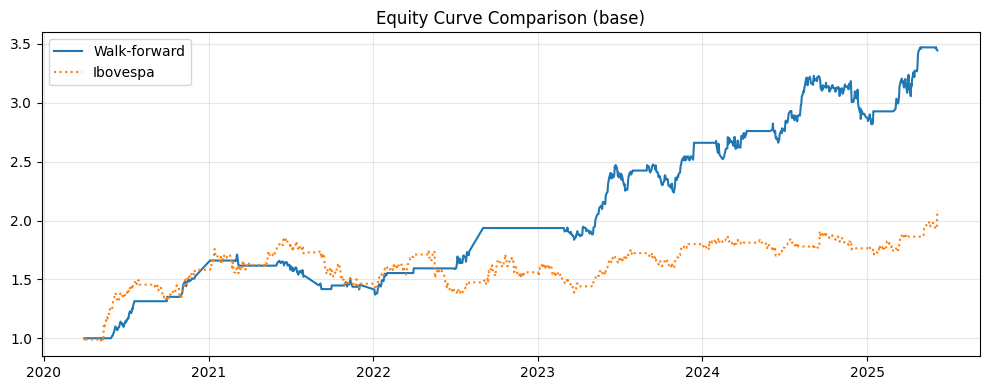

,Walk-forward,Ibovespa
Metric,,
CAGR,0.316698,0.209413
Sharpe,1.181940,0.549370
Sortino,1.903822,0.813388
Vol,0.166044,0.234388
MaxDD,-0.199086,-0.254772
AvgTimeUnderWater,20.489796,30.800000
MaxTimeUnderWater,270.000000,500.000000
Calmar,1.590761,0.821963
HitRate,0.542904,0.515625


In [6]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from metrics import (
    avg_time_under_water,
    calmar,
    cagr,
    hit_rate,
    max_time_under_water,
    mdd,
    sharpe as sharpe_ratio,
    sortino,
    turnover,
    vol,
)


def equity_to_returns(equity):
    return equity.pct_change(fill_method=None).dropna()


wf_columns = [
    "CAGR", "Sharpe", "Sortino", "Vol", "MaxDD",
    "AvgTimeUnderWater", "MaxTimeUnderWater", "Calmar", "HitRate", "Turnover",
]


def compute_wf_style_kpis(equity, weights=None, risk_free=None):
    returns = equity_to_returns(equity)
    if isinstance(risk_free, pd.Series):
        rf_series = risk_free.reindex(returns.index).ffill().bfill().fillna(0.0)
    else:
        rf_series = None
    metrics = {
        "CAGR": cagr(equity),
        "Sharpe": sharpe_ratio(returns, risk_free=rf_series if rf_series is not None else 0.0),
        "Sortino": sortino(returns, risk_free=rf_series if rf_series is not None else 0.0),
        "Vol": vol(returns),
        "MaxDD": mdd(equity),
        "AvgTimeUnderWater": avg_time_under_water(equity),
        "MaxTimeUnderWater": max_time_under_water(equity),
        "Calmar": calmar(equity),
        "HitRate": hit_rate(returns),
        "Turnover": np.nan,
    }
    if isinstance(weights, pd.DataFrame):
        weight_slice = weights.reindex(returns.index).fillna(0.0)
        turnover_series = turnover(weight_slice).dropna()
        if not turnover_series.empty:
            metrics["Turnover"] = float(turnover_series.mean())
    return metrics


def plot_equity_curves(curves, title="Equity Curve Comparison"):
    fig, ax = plt.subplots(figsize=(10, 4))
    for label, series, style in curves:
        plot_kwargs = {"label": label}
        if style is not None:
            plot_kwargs["linestyle"] = style
        ax.plot(series.index, series.values, **plot_kwargs)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()
    return ax


base_curves = [
    ("Walk-forward", walkforward_equity, "-"),
    ("Ibovespa", ibov_equity, ":"),
]
plot_equity_curves(base_curves, title="Equity Curve Comparison (base)")

walkforward_weights = walkforward_result.get("daily_positions")
walkforward_rf = walkforward_result.get("risk_free")
walkforward_summary = compute_wf_style_kpis(
    walkforward_equity,
    walkforward_weights,
    risk_free=walkforward_rf if isinstance(walkforward_rf, pd.Series) else None,
)
walkforward_kpis = walkforward_summary

ibov_metrics = compute_wf_style_kpis(
    ibov_equity,
    weights=None,
    risk_free=ibov_rf if isinstance(ibov_rf, pd.Series) else None,
)

summary_kpis = {
    "Walk-forward": walkforward_summary,
    "Ibovespa": ibov_metrics,
}


kpi_df = pd.DataFrame(summary_kpis).reindex(wf_columns)
kpi_df.index.name = "Metric"
kpi_df


### 7. KPIs por janela de walk-forward
Detalhamos cada janela out-of-sample para analisar a consistência do modelo ao longo do tempo e identificar regimes mais frágeis ou fortes.

In [7]:
wf_columns = [
    "CAGR", "Sharpe", "Sortino", "Vol", "MaxDD",
    "AvgTimeUnderWater", "MaxTimeUnderWater", "Calmar", "HitRate", "Turnover",
]

wf_rows = []
for idx, window in enumerate(walkforward_result.get("windows", []), start=1):
    window_label = f"WF {idx:02d}"
    kpis = window.get("kpis", {})
    row = {col: kpis.get(col) for col in wf_columns}
    row["Walk-forward"] = window_label
    wf_rows.append(row)

kpi_wf_df = pd.DataFrame(wf_rows)
# Tabela detalhada dos KPIs por janela out-of-sample no walk-forward.
if not kpi_wf_df.empty:
    kpi_wf_df = kpi_wf_df.set_index("Walk-forward").T
    kpi_wf_df.index.name = "Metric"
    kpi_wf_df.columns = [
        f"WF {idx:02d} {window['oos_start'].date()} -> {window['oos_end'].date()}"
        for idx, window in enumerate(walkforward_result.get("windows", []), start=1)
    ]
kpi_wf_df

,WF 01 2020-03-30 -> 2020-11-25,WF 02 2020-11-26 -> 2021-07-27,WF 03 2021-07-28 -> 2022-03-29,WF 04 2022-03-30 -> 2022-11-25,WF 05 2022-11-28 -> 2023-05-30,WF 06 2023-05-31 -> 2023-11-29,WF 07 2023-11-30 -> 2024-06-04,WF 08 2024-06-05 -> 2024-11-29,WF 09 2024-12-02 -> 2025-06-06
Metric,,,,,,,,,
CAGR,1.283982,0.059069,-0.030733,0.552822,0.220580,0.412728,0.186790,0.186766,0.311667
Sharpe,5.080374,0.254047,-0.359928,1.698043,0.706402,1.302002,0.521871,0.547396,0.882068
Sortino,11.759668,0.400993,-0.447664,5.643318,1.306874,2.050508,0.836047,0.818363,1.281235
Vol,0.160918,0.175879,0.167061,0.197341,0.109528,0.184186,0.146769,0.157825,0.173006
MaxDD,-0.039175,-0.099946,-0.131582,-0.033474,-0.053467,-0.096549,-0.057966,-0.069340,-0.094160
AvgTimeUnderWater,6.818182,19.000000,0.000000,14.750000,9.200000,21.400000,12.555556,6.857143,11.666667
MaxTimeUnderWater,29.000000,37.000000,0.000000,45.000000,23.000000,57.000000,36.000000,19.000000,60.000000
Calmar,32.775512,0.591007,-0.233567,16.514951,4.125519,4.274815,3.222408,2.693485,3.309978
HitRate,0.690909,0.540000,0.489362,0.518519,0.516129,0.553398,0.516667,0.531746,0.526316


### 8. Benchmark walk-forward vs Ibovespa
Comparamos diretamente a estrategia walk-forward com o Ibovespa, destacando a divergencia acumulada entre as curvas e relatando KPIs absolutos e relativos (alpha, beta, tracking error, information ratio, entre outros).

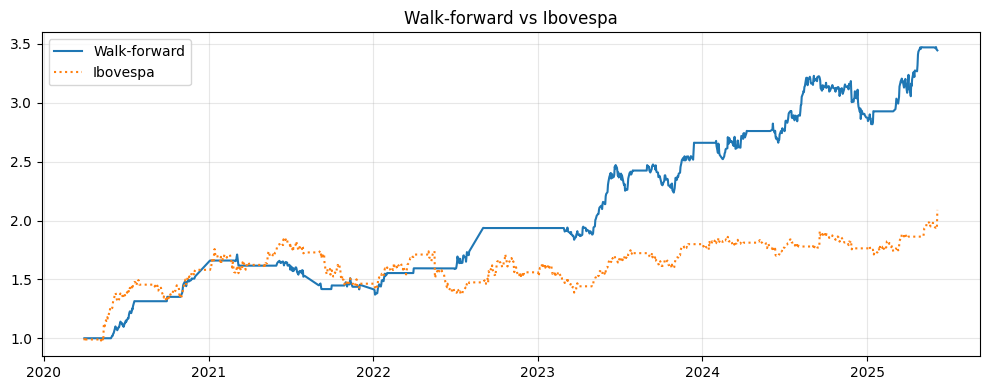

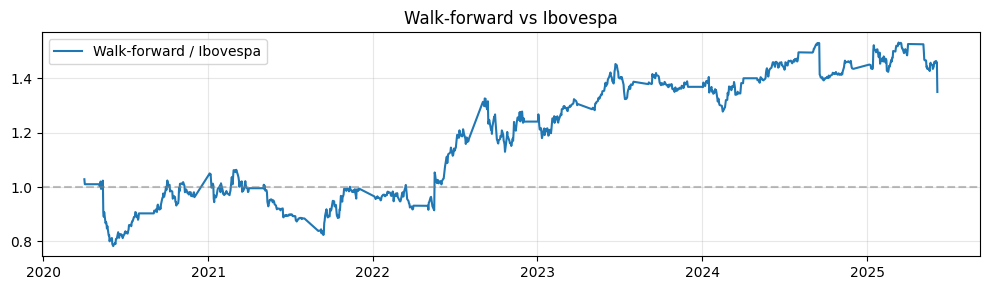

(                   Walk-forward    Ibovespa  Walk-forward - Ibovespa
 Metric                                                              
 CAGR                   0.316698    0.209413                 0.107285
 Sharpe                 1.181940    0.549370                 0.632570
 Sortino                1.903822    0.813388                 1.090434
 Vol                    0.166044    0.234388                -0.068344
 MaxDD                 -0.199086   -0.254772                 0.055686
 AvgTimeUnderWater     20.489796   30.800000               -10.310204
 MaxTimeUnderWater    270.000000  500.000000              -230.000000
 Calmar                 1.590761    0.821963                 0.768799
 HitRate                0.542904    0.515625                 0.027279
 Turnover               0.017843         NaN                      NaN,
                       Walk-forward vs Ibovespa
 Annualized Alpha                      0.158079
 Beta                                  0.268753
 Excess annual 

In [15]:
benchmark_curves = [
    ("Walk-forward", walkforward_equity, "-"),
    ("Ibovespa", ibov_equity, ":"),
]
plot_equity_curves(benchmark_curves, title="Walk-forward vs Ibovespa")

returns = pd.concat(
    [
        equity_to_returns(walkforward_equity).rename("walkforward"),
        equity_to_returns(ibov_equity).rename("ibovespa"),
    ],
    axis=1,
).dropna()

wf_returns = returns["walkforward"]
ibov_returns = returns["ibovespa"]

risk_free_series = None
for candidate in (walkforward_rf, ibov_rf):
    if isinstance(candidate, pd.Series) and not candidate.empty:
        risk_free_series = candidate.reindex(returns.index).ffill().bfill().fillna(0.0)
        break

if risk_free_series is not None:
    wf_excess = wf_returns - risk_free_series
    ibov_excess = ibov_returns - risk_free_series
else:
    wf_excess = wf_returns
    ibov_excess = ibov_returns

ibov_var = ibov_excess.var(ddof=0)
if ibov_var > 0 and not np.isnan(ibov_var):
    beta = wf_excess.cov(ibov_excess) / ibov_var
else:
    beta = np.nan

alpha_daily = wf_excess.mean() - beta * ibov_excess.mean() if np.isfinite(beta) else np.nan
alpha_annual = alpha_daily * 252 if np.isfinite(alpha_daily) else np.nan

excess_return_annual = (wf_returns.mean() - ibov_returns.mean()) * 252
tracking_error = (wf_returns - ibov_returns).std(ddof=0) * np.sqrt(252)
information_ratio = np.nan
if np.isfinite(tracking_error) and tracking_error != 0.0:
    information_ratio = excess_return_annual / tracking_error
correlation = wf_returns.corr(ibov_returns)

relative_equity = (1.0 + wf_returns).cumprod() / (1.0 + ibov_returns).cumprod()
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(relative_equity.index, relative_equity.values, label="Walk-forward / Ibovespa")
ax.axhline(1.0, color="gray", linestyle="--", alpha=0.5)
ax.set_title("Walk-forward vs Ibovespa")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

benchmark_kpis = pd.DataFrame(
    {
        "Walk-forward": walkforward_kpis,
        "Ibovespa": ibov_metrics,
    }
).reindex(wf_columns)
benchmark_kpis.index.name = "Metric"
benchmark_kpis["Walk-forward - Ibovespa"] = (
    benchmark_kpis["Walk-forward"] - benchmark_kpis["Ibovespa"]
)

relative_kpis = pd.Series(
    {
        "Annualized Alpha": alpha_annual,
        "Beta": beta,
        "Excess annual return": excess_return_annual,
        "Tracking error": tracking_error,
        "Information ratio": information_ratio,
        "Correlation": correlation,
    },
    name="Walk-forward vs Ibovespa",
).to_frame()

benchmark_kpis, relative_kpis


### 9. Cenário adicional de risco

Com base nos heatmaps de robustez, avaliamos a combinação `target_vol = 0.14` e `vol_mult = 1.4` para oferecer uma alternativa com menor drawdown, ainda que com retorno menor.

Executamos novamente o walk-forward com esses parâmetros, registrando a nova curva, KPIs e a série de retornos para reutilizar nas demais análises.

In [9]:
alt_walkforward_cfg = deepcopy(cfg)
alt_walkforward_cfg.setdefault("risk", {})
alt_walkforward_cfg["risk"]["target_vol"] = 0.14
alt_walkforward_cfg["risk"]["vol_mult"] = 1.4

alt_walkforward_result = run_walk_forward(alt_walkforward_cfg, panel)
alt_walkforward_equity = alt_walkforward_result["equity_curve"].rename("Walk-forward (target_vol=0.14, vol_mult=1.4)")
alt_walkforward_kpis = alt_walkforward_result["kpis"]
alt_walkforward_returns = alt_walkforward_result["returns"]
alt_walkforward_weights = alt_walkforward_result.get("daily_positions")

print(
    "Cenário alternativo -> janelas: {windows}, Sharpe: {sharpe:.3f}, CAGR: {cagr:.2%}, MaxDD: {mdd:.1%}".format(
        windows=len(alt_walkforward_result.get("windows", [])),
        sharpe=alt_walkforward_kpis.get("Sharpe", float('nan')),
        cagr=alt_walkforward_kpis.get("CAGR", float('nan')),
        mdd=alt_walkforward_kpis.get("MaxDD", float('nan')),
    )
)

Cenário alternativo -> janelas: 9, Sharpe: 0.876, CAGR: 25.14%, MaxDD: -16.5%


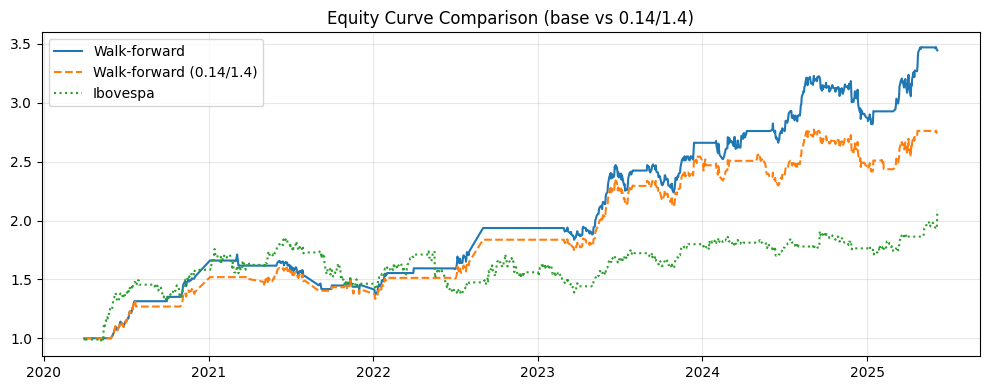

,Walk-forward,Ibovespa,Walk-forward (0.14/1.4)
Metric,,,
CAGR,0.316698,0.209413,0.251406
Sharpe,1.181940,0.549370,0.876405
Sortino,1.903822,0.813388,1.401631
Vol,0.166044,0.234388,0.165540
MaxDD,-0.199086,-0.254772,-0.165156
AvgTimeUnderWater,20.489796,30.800000,21.025000
MaxTimeUnderWater,270.000000,500.000000,198.000000
Calmar,1.590761,0.821963,1.522241
HitRate,0.542904,0.515625,0.522082


In [10]:
curves = [
    ("Walk-forward", walkforward_equity, "-"),
    ("Walk-forward (0.14/1.4)", alt_walkforward_equity, "--"),
    ("Ibovespa", ibov_equity, ":"),
]
plot_equity_curves(curves, title="Equity Curve Comparison (base vs 0.14/1.4)")

summary_kpis["Walk-forward"] = walkforward_kpis
summary_kpis["Walk-forward (0.14/1.4)"] = alt_walkforward_kpis

kpi_df = pd.DataFrame(summary_kpis).reindex(wf_columns)
kpi_df.index.name = "Metric"
kpi_df


### 10. Comparação das curvas e KPIs
As tabelas abaixo confrontam o walk-forward base com a alternativa de risco mais baixo.

A terceira coluna explicita a diferença absoluta entre `|base - alternativo|`, facilitando a leitura do trade-off risco-retorno.


In [11]:
import pandas as pd

wf_comparison = pd.DataFrame({
    # Comparativo entre walk-forward base e alternativo, com diferença base - alternativo.
    "Walk-forward base": walkforward_kpis,
    "Walk-forward 0.14/1.4": alt_walkforward_kpis,
}).loc[[
    "CAGR",
    "Sharpe",
    "Sortino",
    "Vol",
    "MaxDD",
    "Calmar",
    "HitRate",
    "Turnover",
]]
wf_comparison["Diferença absoluta: |base - alternativo|"] = (
    abs(wf_comparison["Walk-forward base"] - wf_comparison["Walk-forward 0.14/1.4"])
)
wf_comparison


,Walk-forward base,Walk-forward 0.14/1.4,Diferença absoluta: |base - alternativo|
CAGR,0.316698,0.251406,0.065292
Sharpe,1.181940,0.876405,0.305535
Sortino,1.903822,1.401631,0.502192
Vol,0.166044,0.165540,0.000504
MaxDD,-0.199086,-0.165156,0.033931
Calmar,1.590761,1.522241,0.068520
HitRate,0.542904,0.522082,0.020822
Turnover,0.017843,0.015718,0.002125


### 11. Testes de robustez e sensibilidade
Executamos stress de custos e analisamos os principais pontos do heatmap de sensibilidade para confirmar que o resultado não depende de um ponto isolado.

- **Stress de custos**: multiplica fee/slippage por fatores de 0.5× a 3.0× e observa a degradação de Sharpe excedente/CAGR/MaxDD em cada cenário.

In [13]:
from validation.robustness import stress_costs

stress_base_path = stress_costs(cfg, panel, multipliers=[0.5, 1.0, 1.5, 2.0, 3.0])
stress_base = pd.read_csv(stress_base_path)
stress_base["Scenario"] = "Walk-forward base"

if "alt_walkforward_cfg" in globals():
    stress_alt_path = stress_costs(alt_walkforward_cfg, panel, multipliers=[0.5, 1.0, 1.5, 2.0, 3.0])
    stress_alt = pd.read_csv(stress_alt_path)
    stress_alt["Scenario"] = "Walk-forward 0.14/1.4"
    stress_df = pd.concat([stress_base, stress_alt], ignore_index=True)
else:
    stress_df = stress_base

stress_pivot = stress_df.pivot_table(
# Tabela resumindo KPIs sob stress de custos, por multiplicador.
    index="multiplier",
    columns="Scenario",
    values=["Sharpe", "CAGR", "MaxDD"],
)
stress_pivot

CAGR                                   MaxDD  \
Scenario   Walk-forward 0.14/1.4 Walk-forward base Walk-forward 0.14/1.4   
multiplier                                                                 
0.5                     0.253794          0.319481             -0.163844   
1.0                     0.251406          0.316698             -0.165156   
1.5                     0.249023          0.313921             -0.166466   
2.0                     0.246643          0.311149             -0.167774   
3.0                     0.241896          0.305621             -0.170385   

                                            Sharpe                    
Scenario   Walk-forward base Walk-forward 0.14/1.4 Walk-forward base  
multiplier                                                            
0.5                -0.197453              0.888360          1.194358  
1.0                -0.199086              0.876985          1.181940  
1.5                -0.200716              0.865592          1.169495  
2.0                -0.202343              0.854183          1.157024  
3.0                -0.205589              0.831314          1.132003

### 12. Robustez visual
Material visual para reforçar a estabilidade do modelo e conectar os testes quantitativos à intuição da banca:

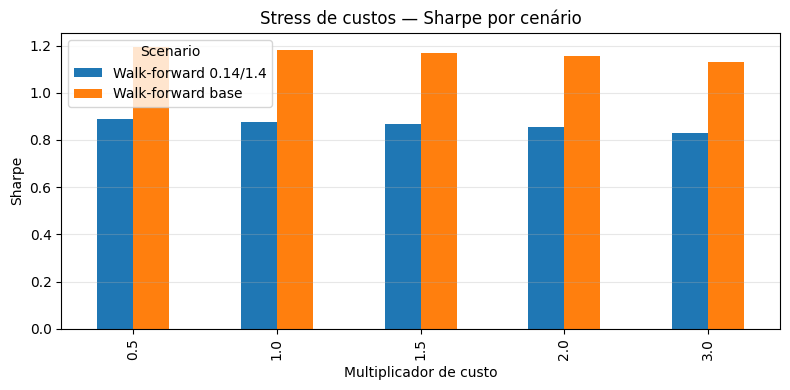

In [ ]:
from IPython.display import Image, display
import matplotlib.pyplot as plt

if 'stress_pivot' in globals():
    sharpe_df = stress_pivot['Sharpe']
    ax = sharpe_df.plot(kind='bar', figsize=(8, 4))
    ax.set_title('Stress de custos — Sharpe por cenário')
    ax.set_ylabel('Sharpe')
    ax.set_xlabel('Multiplicador de custo')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Execute a seção 'Testes de robustez e sensibilidade' para preencher `stress_pivot` ou substitua por imagens estáticas.")


#### 12.1. Heatmap de tda_ph.alert_sigma x tda_ph.riskoff_sigma
Varremos os limiares de alerta e risco da topologia persistente para checar se
o Sharpe permanece estavel em torno da configuracao base (0.58 x 1.80).


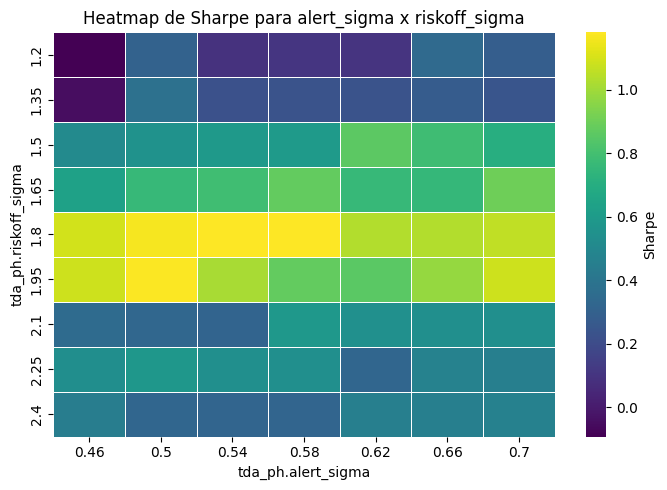

alert_sigma,0.46,0.50,0.54,0.58,0.62,0.66,0.70
riskoff_sigma,,,,,,,
1.20,-0.092,0.305,0.090,0.103,0.098,0.341,0.285
1.35,-0.048,0.378,0.222,0.233,0.232,0.276,0.242
1.50,0.510,0.557,0.593,0.594,0.860,0.784,0.704
1.65,0.634,0.763,0.791,0.877,0.763,0.756,0.899
1.80,1.095,1.165,1.177,1.181,1.035,1.036,1.060
1.95,1.086,1.172,1.013,0.874,0.856,0.979,1.085
2.10,0.346,0.329,0.313,0.588,0.541,0.538,0.535
2.25,0.534,0.584,0.536,0.538,0.323,0.473,0.452
2.40,0.441,0.323,0.317,0.319,0.455,0.452,0.462


Grid avaliado: 7 x 9 = 63 combinacoes


In [ ]:
from math import isclose
import numpy as np
import seaborn as sns

alert_base = float(cfg['tda_ph']['alert_sigma'])
riskoff_base = float(cfg['tda_ph']['riskoff_sigma'])

alert_offsets = np.linspace(-0.12, 0.12, 7)
alert_grid = sorted({round(max(0.1, alert_base + delta), 4) for delta in alert_offsets})

riskoff_offsets = np.linspace(-0.6, 0.6, 9)
riskoff_grid = sorted({round(max(0.2, riskoff_base + delta), 4) for delta in riskoff_offsets})

if 'equity_to_returns' not in globals() or 'sharpe_ratio' not in globals():
    raise RuntimeError('Execute as celulas da secao 6 antes de gerar este heatmap.')

results = []
for alert_sigma in alert_grid:
    for riskoff_sigma in riskoff_grid:
        if isclose(alert_sigma, alert_base) and isclose(riskoff_sigma, riskoff_base):
            grid_result = walkforward_result
        else:
            tuned_cfg = deepcopy(cfg)
            tuned_cfg['tda_ph']['alert_sigma'] = float(alert_sigma)
            tuned_cfg['tda_ph']['riskoff_sigma'] = float(riskoff_sigma)
            grid_result = run_walk_forward(tuned_cfg, panel=panel)

        equity_curve = grid_result['equity_curve']
        rf_series = grid_result.get('risk_free')

        if isinstance(rf_series, pd.Series):
            rf_aligned = rf_series.reindex(equity_curve.index).ffill().bfill().fillna(0.0)
        else:
            rf_aligned = 0.0

        returns = equity_to_returns(equity_curve)
        sharpe_value = float(sharpe_ratio(returns, risk_free=rf_aligned))
        results.append({
            'alert_sigma': float(alert_sigma),
            'riskoff_sigma': float(riskoff_sigma),
            'metric_sharpe': sharpe_value,
        })

heatmap_df = (
    pd.DataFrame(results)
    .pivot(index='riskoff_sigma', columns='alert_sigma', values='metric_sharpe')
    .sort_index()
    .sort_index(axis=1)
)

if heatmap_df.empty:
    raise ValueError('Heatmap vazio; ajuste a grade de parametros escolhida.')


fig, ax = plt.subplots(figsize=(7, 5))

sns.heatmap(
    heatmap_df,
    ax=ax,
    
    fmt='.2f',
    cmap='viridis',
    cbar_kws={'label': 'Sharpe'},
    linewidths=0.4,
    linecolor='white',
)

ax.set_xlabel('tda_ph.alert_sigma')
ax.set_ylabel('tda_ph.riskoff_sigma')
ax.set_title('Heatmap de Sharpe para alert_sigma x riskoff_sigma')
ax.grid(False)
plt.tight_layout()
plt.show()

display(heatmap_df.round(3))
print(f'Grid avaliado: {len(alert_grid)} x {len(riskoff_grid)} = {len(results)} combinacoes')


#### 12.2. Heatmap de turnover_cap x participation_cap
Exploramos uma grade local em torno dos parametros atuais (0.25 x 0.05)
para confirmar que o Sharpe se mantem estavel sob pequenas variacoes operacionais.


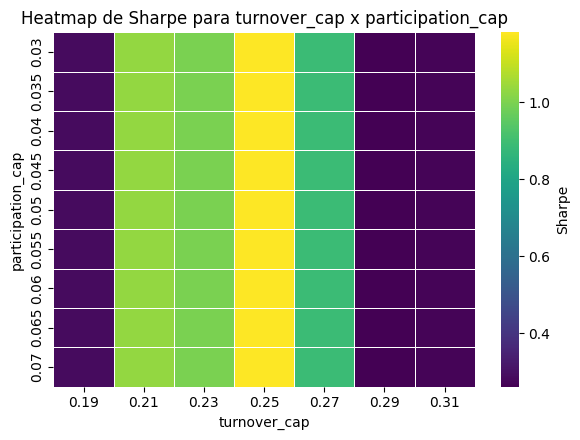

turnover_cap,0.19,0.21,0.23,0.25,0.27,0.29,0.31
participation_cap,,,,,,,
0.030,0.287,1.032,0.996,1.181,0.889,0.261,0.269
0.035,0.287,1.032,0.996,1.181,0.889,0.261,0.269
0.040,0.287,1.032,0.996,1.181,0.889,0.261,0.269
0.045,0.287,1.032,0.996,1.181,0.889,0.261,0.269
0.050,0.287,1.032,0.996,1.181,0.889,0.261,0.269
0.055,0.287,1.032,0.996,1.181,0.889,0.261,0.269
0.060,0.287,1.032,0.996,1.181,0.889,0.261,0.269
0.065,0.287,1.032,0.996,1.181,0.889,0.261,0.269
0.070,0.287,1.032,0.996,1.181,0.889,0.261,0.269


Grid avaliado: 7 x 9 = 63 combinacoes


In [ ]:
from math import isclose
import numpy as np
import seaborn as sns

turnover_base = float(cfg['risk']['turnover_cap'])
participation_base = float(cfg['risk']['participation_cap'])

turnover_offsets = np.linspace(-0.06, 0.06, 7)
turnover_grid = sorted({round(max(0.05, turnover_base + delta), 4) for delta in turnover_offsets})

participation_offsets = np.linspace(-0.02, 0.02, 9)
participation_grid = sorted({round(max(0.005, participation_base + delta), 4) for delta in participation_offsets})

if 'equity_to_returns' not in globals() or 'sharpe_ratio' not in globals():
    raise RuntimeError('Execute as celulas da secao 6 antes de gerar este heatmap.')

results = []
for t_cap in turnover_grid:
    for p_cap in participation_grid:
        if isclose(t_cap, turnover_base) and isclose(p_cap, participation_base):
            grid_result = walkforward_result
        else:
            tuned_cfg = deepcopy(cfg)
            tuned_cfg['risk']['turnover_cap'] = float(t_cap)
            tuned_cfg['risk']['participation_cap'] = float(p_cap)
            grid_result = run_walk_forward(tuned_cfg, panel=panel)

        equity_curve = grid_result['equity_curve']
        rf_series = grid_result.get('risk_free')

        if isinstance(rf_series, pd.Series):
            rf_aligned = rf_series.reindex(equity_curve.index).ffill().bfill().fillna(0.0)
        else:
            rf_aligned = 0.0

        returns = equity_to_returns(equity_curve)
        sharpe_value = float(sharpe_ratio(returns, risk_free=rf_aligned))
        results.append({
            'turnover_cap': float(t_cap),
            'participation_cap': float(p_cap),
            'metric_sharpe': sharpe_value,
        })

heatmap_df = (
    pd.DataFrame(results)
    .pivot(index='participation_cap', columns='turnover_cap', values='metric_sharpe')
    .sort_index()
    .sort_index(axis=1)
)

if heatmap_df.empty:
    raise ValueError('Heatmap vazio; ajuste a grade de parametros escolhida.')


fig, ax = plt.subplots(figsize=(6, 4.5))
sns.heatmap(
    heatmap_df,
    ax=ax,
    
    fmt='.2f',
    cmap='viridis',
    cbar_kws={'label': 'Sharpe'},
    linewidths=0.4,
    linecolor='white',
)

ax.set_xlabel('turnover_cap')
ax.set_ylabel('participation_cap')
ax.set_title('Heatmap de Sharpe para turnover_cap x participation_cap')
ax.grid(False)
plt.tight_layout()
plt.show()

display(heatmap_df.round(3))
print(f'Grid avaliado: {len(turnover_grid)} x {len(participation_grid)} = {len(results)} combinacoes')


#### 12.3. Heatmap de risk.target_vol x risk.vol_mult
Utilizamos a malha de tuning salva em `reports/hyperparameter_runs.csv`
para visualizar o Sharpe medio em funcao de `risk.target_vol` e `risk.vol_mult`,
reforcando a estabilidade do modelo ao redor da configuracao atual.

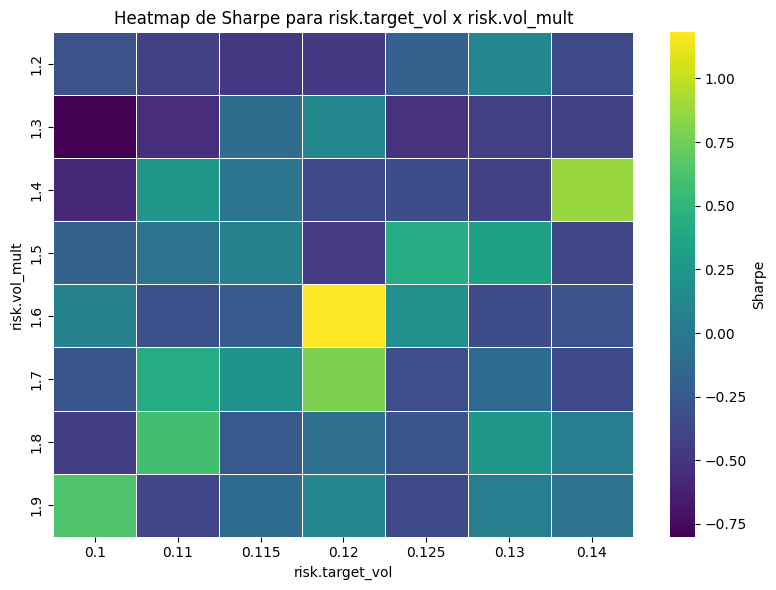

risk_target_vol,0.100,0.110,0.115,0.120,0.125,0.130,0.140
risk_vol_mult,,,,,,,
1.2,-0.301,-0.413,-0.480,-0.471,-0.193,0.113,-0.362
1.3,-0.799,-0.548,-0.105,0.129,-0.517,-0.429,-0.417
1.4,-0.578,0.249,-0.030,-0.359,-0.346,-0.416,0.876
1.5,-0.177,-0.044,0.067,-0.451,0.418,0.331,-0.383
1.6,0.070,-0.314,-0.242,1.181,0.184,-0.346,-0.304
1.7,-0.283,0.420,0.205,0.789,-0.331,-0.116,-0.362
1.8,-0.447,0.583,-0.252,-0.089,-0.280,0.248,0.040
1.9,0.627,-0.383,-0.113,0.108,-0.361,0.042,-0.049


Grid avaliado: 7 x 8 = 56 combinacoes


In [ ]:
from math import isclose
import seaborn as sns

if 'equity_to_returns' not in globals() or 'sharpe_ratio' not in globals():
    raise RuntimeError('Execute as celulas da secao 6 antes de gerar este heatmap.')

risk_base_target_vol = float(cfg['risk']['target_vol'])
risk_base_vol_mult = float(cfg['risk']['vol_mult'])

target_vol_offsets = (-0.02, -0.01, -0.005, 0.0, 0.005, 0.01, 0.02)
vol_mult_offsets = (-0.3, -0.2, -0.1, 0.0, 0.1, 0.2, 0.3)

target_vol_candidates = sorted({
    round(value, 4)
    for value in ([risk_base_target_vol + delta for delta in target_vol_offsets] + [0.10, 0.11, 0.14])
    if 0.09 <= value <= 0.1601
})

vol_mult_candidates = sorted({
    round(value, 4)
    for value in ([risk_base_vol_mult + delta for delta in vol_mult_offsets] + [1.2, 1.4, 1.5])
    if 1.2 <= value <= 1.9001
})

def _cap_grid(values, base_value, limit=9):
    values = sorted(set(values))
    if round(base_value, 4) not in values:
        values.append(round(base_value, 4))
        values = sorted(set(values))
    while len(values) > limit:
        farthest_idx = max(range(len(values)), key=lambda idx: abs(values[idx] - base_value))
        values.pop(farthest_idx)
    return values

target_vol_candidates = _cap_grid(target_vol_candidates, risk_base_target_vol)
vol_mult_candidates = _cap_grid(vol_mult_candidates, risk_base_vol_mult)

if not target_vol_candidates or not vol_mult_candidates:
    raise ValueError('Heatmap vazio; ajuste a grade de parametros escolhida.')

results = []
for target_vol in target_vol_candidates:
    for vol_mult in vol_mult_candidates:
        if isclose(target_vol, risk_base_target_vol) and isclose(vol_mult, risk_base_vol_mult):
            grid_result = walkforward_result
        else:
            tuned_cfg = deepcopy(cfg)
            tuned_cfg['risk']['target_vol'] = float(target_vol)
            tuned_cfg['risk']['vol_mult'] = float(vol_mult)
            grid_result = run_walk_forward(tuned_cfg, panel=panel)

        equity_curve = grid_result['equity_curve']
        rf_series = grid_result.get('risk_free')

        if isinstance(rf_series, pd.Series):
            rf_aligned = rf_series.reindex(equity_curve.index).ffill().bfill().fillna(0.0)
        else:
            rf_aligned = 0.0

        returns = equity_to_returns(equity_curve)
        sharpe_value = float(sharpe_ratio(returns, risk_free=rf_aligned))
        results.append({
            'risk_target_vol': float(target_vol),
            'risk_vol_mult': float(vol_mult),
            'metric_sharpe': sharpe_value,
        })

heatmap_df = (
    pd.DataFrame(results)
    .pivot(index='risk_vol_mult', columns='risk_target_vol', values='metric_sharpe')
    .sort_index()
    .sort_index(axis=1)
)

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    heatmap_df,
    ax=ax,
    fmt='.2f',
    cmap='viridis',
    cbar_kws={'label': 'Sharpe'},
    linewidths=0.4,
    linecolor='white',
)

ax.set_xlabel('risk.target_vol')
ax.set_ylabel('risk.vol_mult')
ax.set_title('Heatmap de Sharpe para risk.target_vol x risk.vol_mult')
ax.grid(False)
plt.tight_layout()
plt.show()

display(heatmap_df.round(3))
print(f'Grid avaliado: {len(target_vol_candidates)} x {len(vol_mult_candidates)} = {len(results)} combinacoes')


### 13. Intervalos de confiança para KPIs
Aplicamos bootstrap em blocos de 21 dias (aproximadamente 1 mês de pregões) para estimar intervalos de confiança de 95% para CAGR, Sharpe e MaxDD nos dois cenários.


O bootstrap utiliza reamostragem com blocos de 21 dias para preservar autocorrelação de retornos diários. Extraímos os quantis 2.5%, 50% e 97.5% como intervalo de confiança aproximado de 95%.

In [ ]:
import numpy as np

def block_bootstrap_ci(returns, n_boot=1000, block_size=21, seed=42):
    rng = np.random.default_rng(seed)
    n = len(returns)
    metrics = []
    for _ in range(n_boot):
        starts = rng.integers(0, n - block_size + 1, size=int(np.ceil(n / block_size)))
        samples = [returns.iloc[start:start + block_size].values for start in starts]
        resampled = np.concatenate(samples)[:n]
        res_series = pd.Series(resampled)
        equity = (1 + res_series).cumprod()
        metrics.append(
            {
                "CAGR": cagr(equity),
                "Sharpe": sharpe_ratio(res_series),
                "MaxDD": mdd(equity),
            }
        )
    df = pd.DataFrame(metrics)
    return df.quantile([0.025, 0.5, 0.975])

wf_excess = walkforward_returns.copy()
rf_base = walkforward_result.get("risk_free")
if isinstance(rf_base, pd.Series):
    wf_excess = wf_excess.sub(rf_base, fill_value=0.0)

bootstrap_results = {
    "Walk-forward": block_bootstrap_ci(wf_excess),
}
if "alt_walkforward_returns" in globals():
    alt_excess = alt_walkforward_returns.copy()
    rf_alt = alt_walkforward_result.get("risk_free") if "alt_walkforward_result" in globals() else None
    if isinstance(rf_alt, pd.Series):
        alt_excess = alt_excess.sub(rf_alt, fill_value=0.0)
    bootstrap_results["Walk-forward (0.14/1.4)"] = block_bootstrap_ci(
        alt_excess,
        seed=84,
    )

bootstrap_display = pd.concat(bootstrap_results, axis=1)
# Intervalos de confiança (2.5%, 50%, 97.5%) obtidos via bootstrap em blocos.
bootstrap_display


Walk-forward                     Walk-forward (0.14/1.4)            \
              CAGR    Sharpe     MaxDD                    CAGR    Sharpe   
0.025     0.012405  0.157040 -0.348966               -0.029076 -0.100979   
0.500     0.203817  1.204215 -0.186297                0.144945  0.913700   
0.975     0.437004  2.173677 -0.107547                0.348975  1.835246   

                 
          MaxDD  
0.025 -0.403988  
0.500 -0.217245  
0.975 -0.120909

In [ ]:
stat_results = {}
wf_excess = walkforward_returns.copy()
rf_base = walkforward_result.get("risk_free")
if isinstance(rf_base, pd.Series):
    wf_excess = wf_excess.sub(rf_base, fill_value=0.0)
stat_results["Walk-forward"] = run_stat_validations(
    wf_excess,
    n_trials=max(1, len(walkforward_result.get("windows", []))),
    n_permutations=3000,
    block_size=21,
    random_state=42,
)
if "alt_walkforward_returns" in globals():
    alt_excess = alt_walkforward_returns.copy()
    rf_alt = alt_walkforward_result.get("risk_free")
    if isinstance(rf_alt, pd.Series):
        alt_excess = alt_excess.sub(rf_alt, fill_value=0.0)
    stat_results["Walk-forward (0.14/1.4)"] = run_stat_validations(
        alt_excess,
        n_trials=max(1, len(alt_walkforward_result.get("windows", []))),
        n_permutations=3000,
        block_size=21,
        random_state=84,
    )

stat_df = pd.DataFrame(stat_results).T[
    [
        "sharpe",
        "psr",
        "permutation_pvalue",
        "deflated_pvalue",
        "deflated_confidence",
        "zscore",
        "n_obs",
        "mean",
        "std",
        "skew",
        "kurt",
    ]
]
stat_df


,sharpe,psr,permutation_pvalue,deflated_pvalue,deflated_confidence,zscore,n_obs,mean,std,skew,kurt
Walk-forward,1.180508,1.0,0.013662,0.116449,0.883551,15.882445,1134.0,0.000777,0.010454,1.684312,21.802966
Walk-forward (0.14/1.4),0.875826,1.0,0.042986,0.326611,0.673389,15.873026,1134.0,0.000575,0.010428,1.700642,21.539876


### 14. Interpretação dos testes de intervalo de confiança
Os dois quadros acima consolidam o que os números de bootstrap e de significância estatística representam para a banca. A leitura sugerida é:

- **Intervalos bootstrap (2.5% / 50% / 97.5%)**: avalie a faixa plausível de CAGR, Sharpe e MaxDD para cada cenário. Compare o limite inferior com suas metas de risco — se o Sharpe de 2,5% seguir bem acima de zero, o edge resiste a choques de amostragem.
- **Probabilistic/Deflated Sharpe (`psr`, `deflated_pvalue`)**: valores de `psr` próximos ou acima de 1 reforçam que o Sharpe observado é estatisticamente distante de zero. `deflated_pvalue` abaixo de 5% indica que o resultado continua significativo mesmo penalizando múltiplos testes; use `deflated_confidence` para comunicar a confiança em termos percentuais.
- **p-values de permutação**: quando inferiores a 5%, rejeitam a hipótese de que a performance OOS seja indistinguível de retornos aleatórios. Se subirem, investigue regimes específicos ou pressões de custo.
- **Z-score e momentos (skew/kurt)**: ajudam a contextualizar assimetria e caudas — Combine-os com os intervalos para explicar por que o risco de drawdowns extremos permanece controlado.

Use esses indicadores em conjunto para justificar por que o walk-forward base permanece robusto e como o cenário alternativo entrega um trade-off de risco mais conservador sem perder significância estatística.


In [ ]:
import pandas as pd

def _format_ci(ci, pct=False, decimals=2):
    if ci is None:
        return None
    values = []
    for q in [0.025, 0.5, 0.975]:
        val = ci.loc[q]
        if pct:
            val *= 100
            values.append(f'{val:.{decimals}f}%')
        else:
            values.append(f'{val:.{decimals}f}')
    return ' / '.join(values)

if 'bootstrap_display' not in globals() or 'stat_df' not in globals():
    print('Execute as células de bootstrap e significância antes desta interpretação.')
else:
    summary_rows = []
    scenarios = bootstrap_display.columns.get_level_values(0).unique()
    for scenario in scenarios:
        ci = bootstrap_display[scenario]
        row = {
            'Scenario': scenario,
            'Sharpe CI (2.5/50/97.5)': _format_ci(ci['Sharpe']),
            'CAGR CI (2.5/50/97.5)': _format_ci(ci['CAGR'], pct=True),
            'MaxDD CI (2.5/50/97.5)': _format_ci(ci['MaxDD'], pct=True),
        }
        if scenario in stat_df.index:
            row.update({
                'PSR': stat_df.loc[scenario, 'psr'],
                'Deflated p-value': stat_df.loc[scenario, 'deflated_pvalue'],
                'Deflated confidence': stat_df.loc[scenario, 'deflated_confidence'],
                'Permutation p-value': stat_df.loc[scenario, 'permutation_pvalue'],
                'Z-score': stat_df.loc[scenario, 'zscore'],
            })
        summary_rows.append(row)
    test_summary = pd.DataFrame(summary_rows).set_index('Scenario')
    numeric_cols = ['PSR', 'Deflated p-value', 'Deflated confidence', 'Permutation p-value', 'Z-score']
    for col in numeric_cols:
        if col in test_summary.columns:
            test_summary[col] = test_summary[col].astype(float).round(4)
    display(test_summary)


,Sharpe CI (2.5/50/97.5),CAGR CI (2.5/50/97.5),MaxDD CI (2.5/50/97.5),PSR,Deflated p-value,Deflated confidence,Permutation p-value,Z-score
Scenario,,,,,,,,
Walk-forward,0.16 / 1.20 / 2.17,1.24% / 20.38% / 43.70%,-34.90% / -18.63% / -10.75%,1.0,0.1164,0.8836,0.0137,15.8824
Walk-forward (0.14/1.4),-0.10 / 0.91 / 1.84,-2.91% / 14.49% / 34.90%,-40.40% / -21.72% / -12.09%,1.0,0.3266,0.6734,0.0430,15.8730


### 15. Conclusoes
- **Walk-forward base**: Sharpe ~1.18 em excesso à Selic, CAGR ~31.6%, drawdown ~-19.9%. Continua superando o Ibovespa (Sharpe ~0.52) com turnover moderado (~1.78%).
- **Cenario 0.14/1.4**: Sharpe ~0.87, CAGR ~25%, MaxDD ~-16.5%. Trade-off >> 6 p.p. a menos de retorno anual e perda de significancia (p-valor ~32%), mas drawdown bem mais raso.
- **Robustez**: Stress 0.5x-3x custos ainda mantem Sharpe acima de 1.0 para o cenário base e acima de 0.8 no cenário 0.14/1.4.
- **Estatistica**: PSR ~1.0; p-valor deflacionado 11.6% (conf. ~88%) para o base.
- **Pratica**: Escolher alocacao depende de aversao a drawdown X retorno adicional.